### Missing Values Processing

In [2]:
import pandas as pd
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.impute import SimpleImputer, KNNImputer

After overviewing the data, we eliminate features that are filled with a single value since they do not provide useful information for models.

In [4]:
Data = pd.read_csv('../Data/FPD.csv')

constant_cols = [col for col in Data.columns if Data[col].nunique() == 1]
Data = Data.drop(columns=constant_cols)
print("Constant columns eliminated:", constant_cols)

Constant columns eliminated: ['feature_59', 'feature_67', 'feature_68', 'feature_69', 'feature_70']


next, we ignore ID wich is unique for each row and therefore, it also does not help the model at all. we also use imputation to fill NaN values

In [6]:
Data_numeric = Data.drop(columns=['ID'], errors='ignore')

for col in Data_numeric.columns:
    if Data_numeric[col].dtype == 'bool':
        Data_numeric[col] = Data_numeric[col].astype(int)


knn_imputer = KNNImputer(n_neighbors=5)
Data_imputed_knn = pd.DataFrame(knn_imputer.fit_transform(Data_numeric), columns=Data_numeric.columns)
Data = Data_imputed_knn

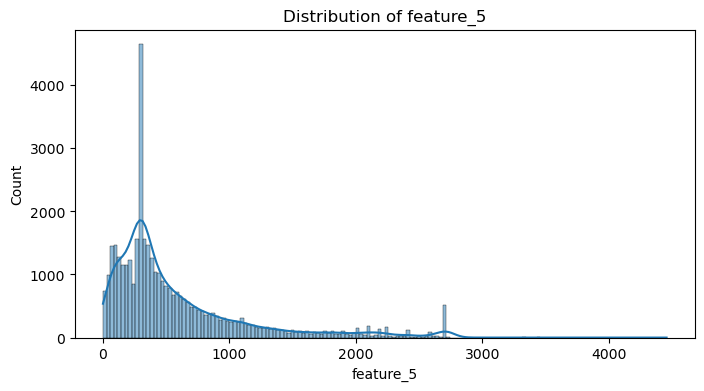

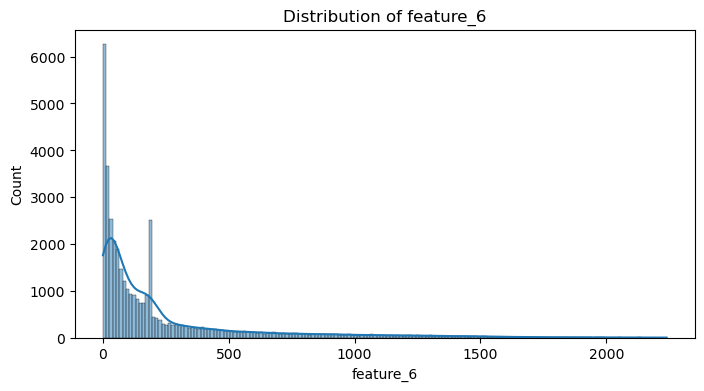

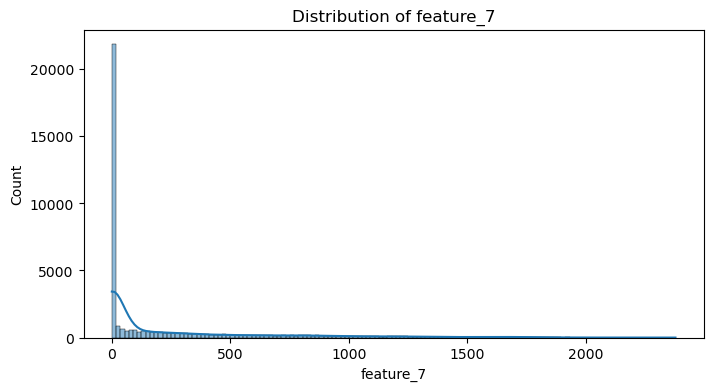

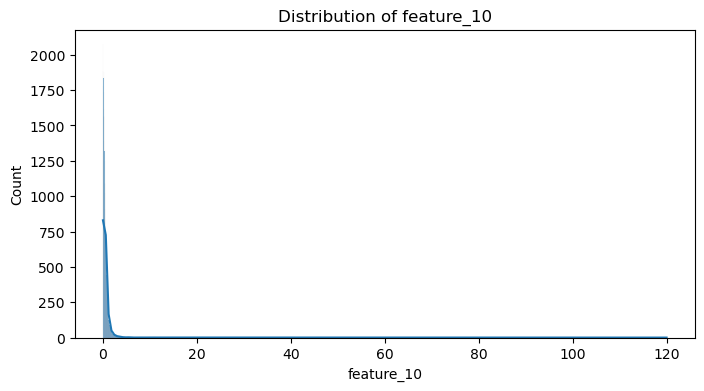

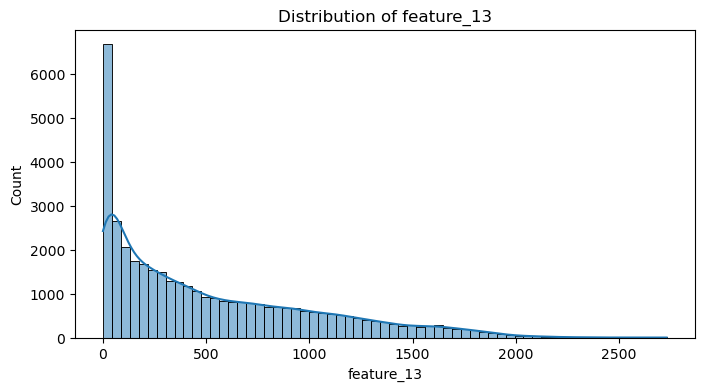

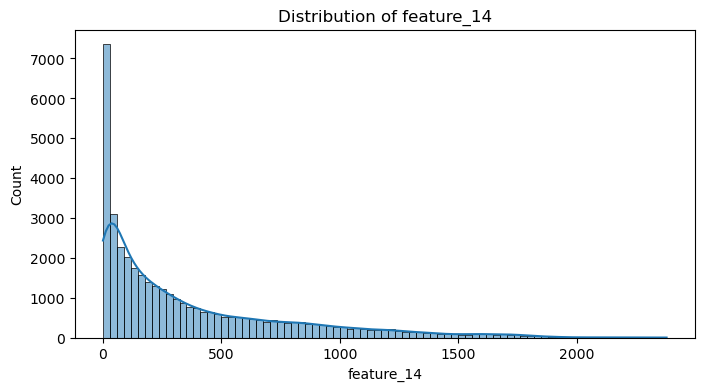

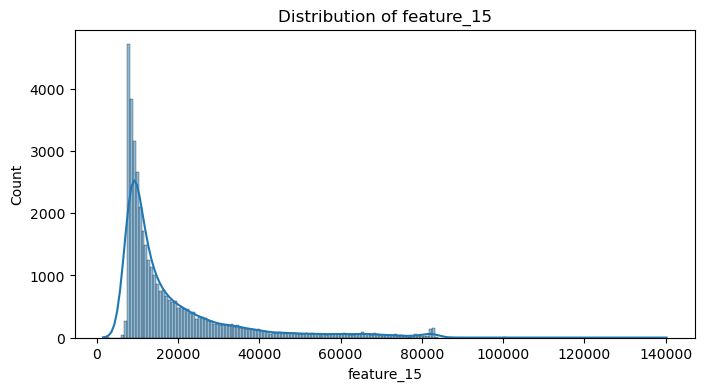

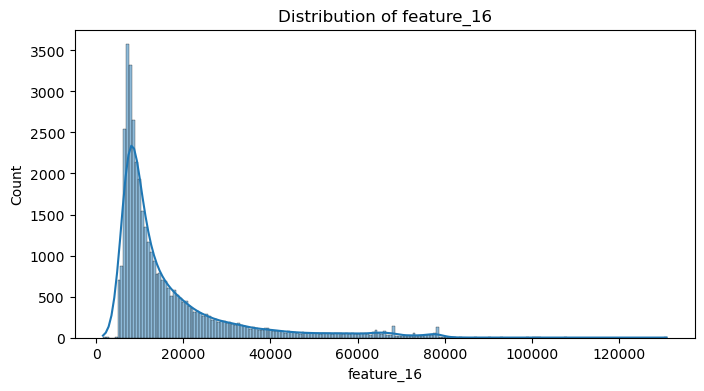

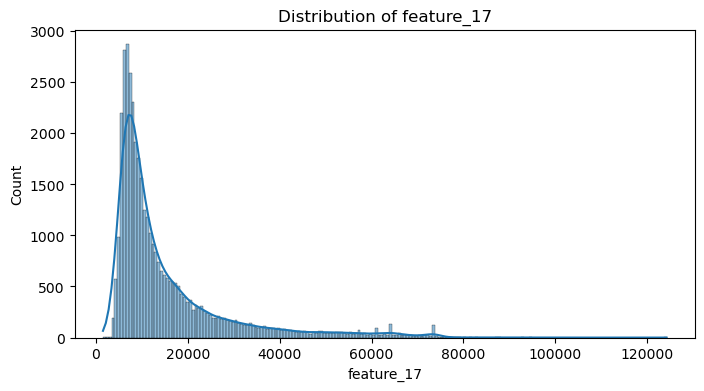

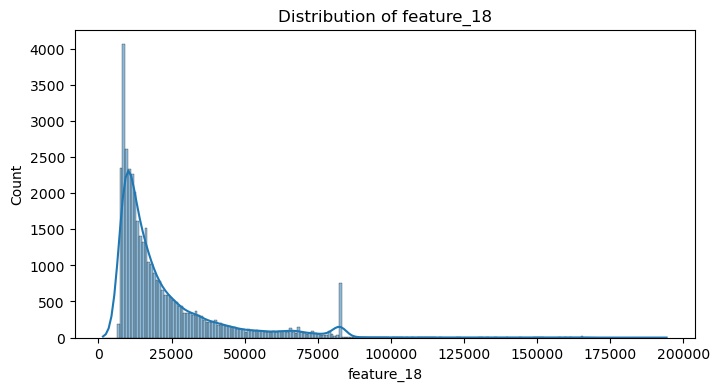

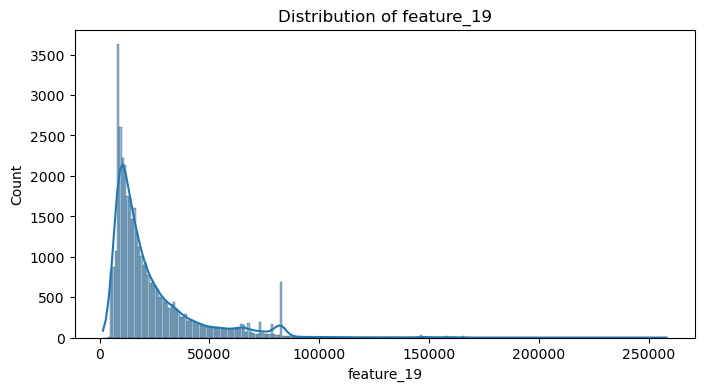

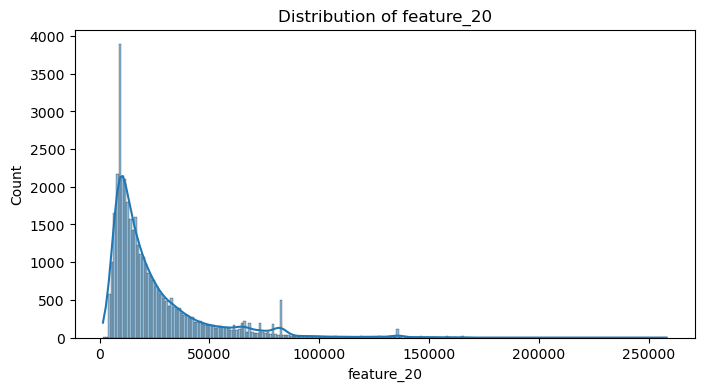

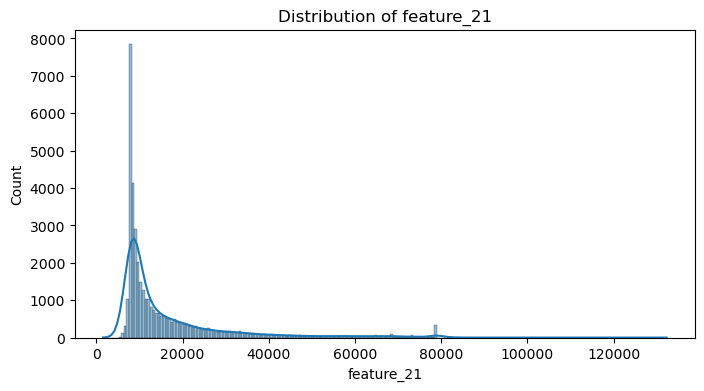

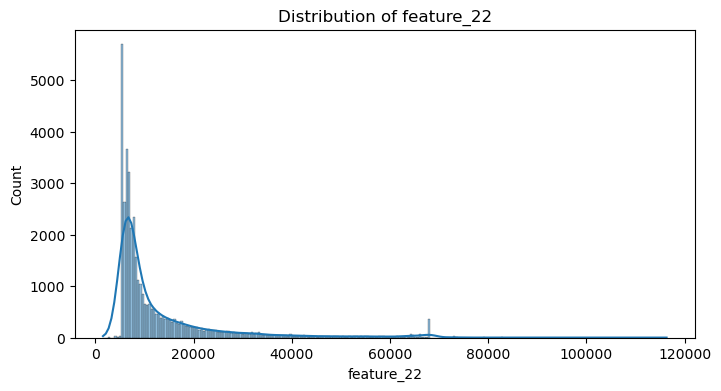

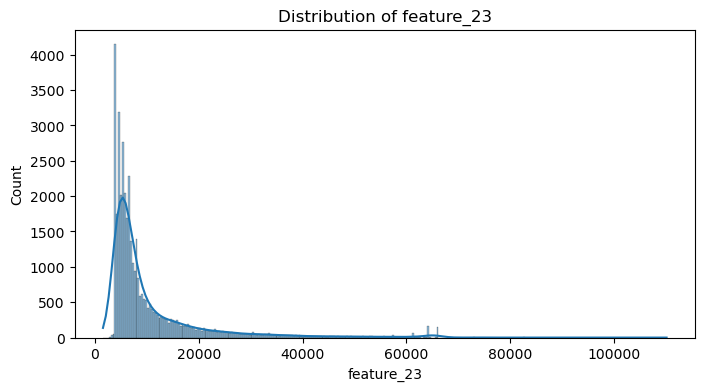

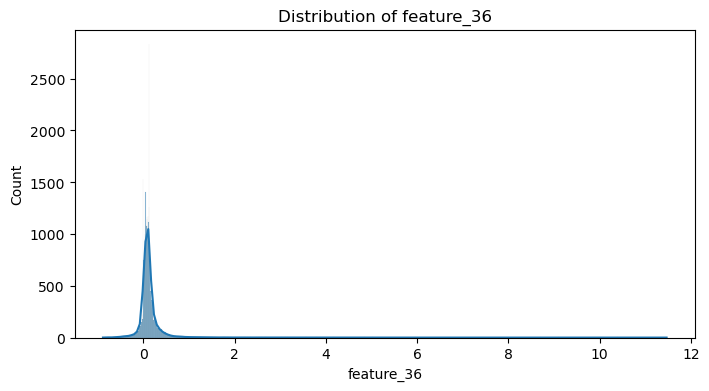

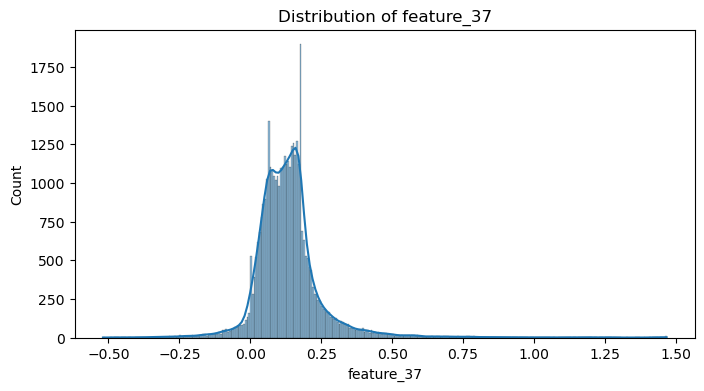

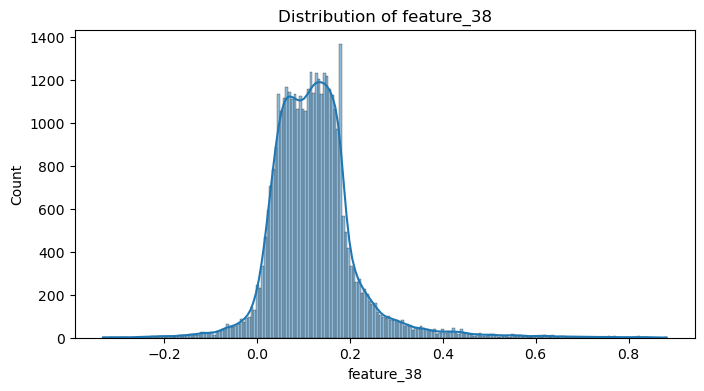

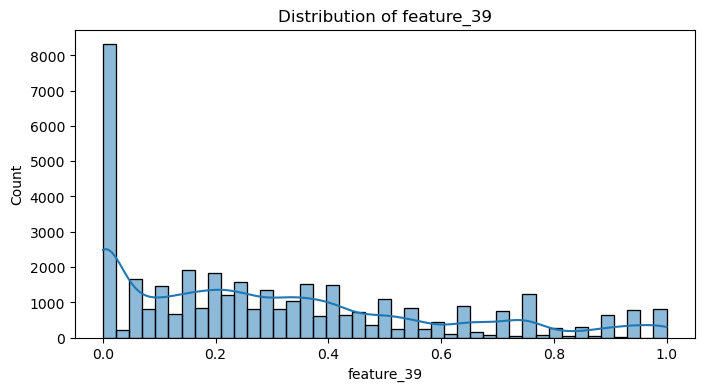

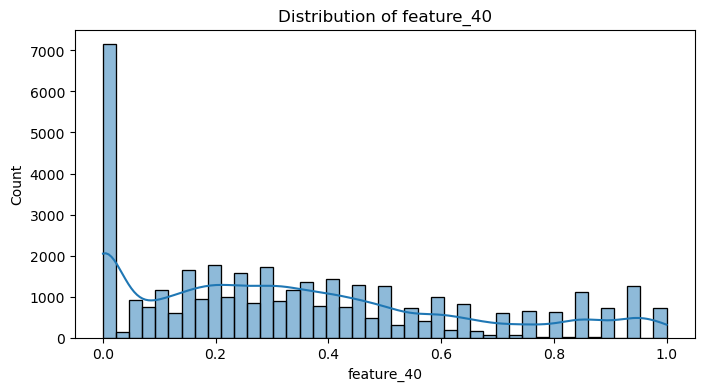

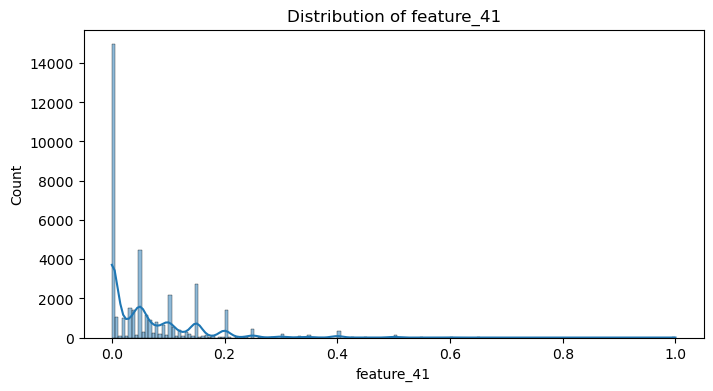

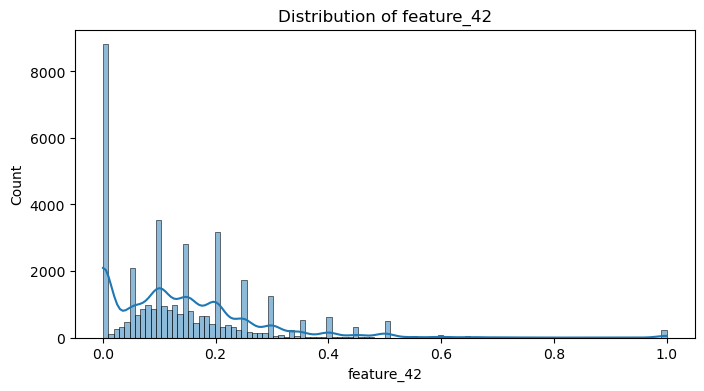

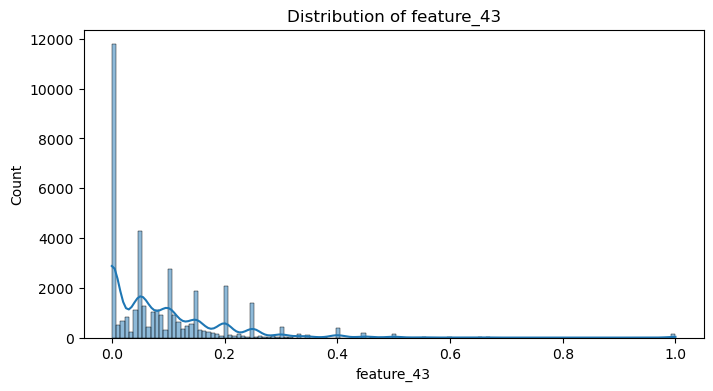

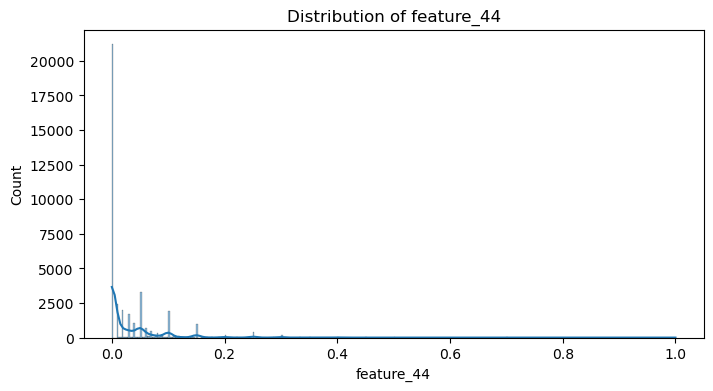

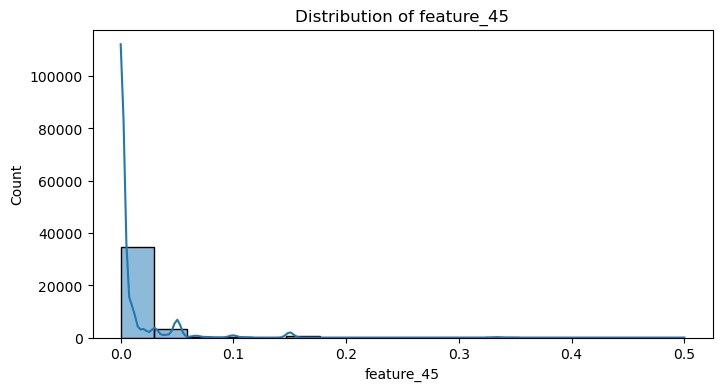

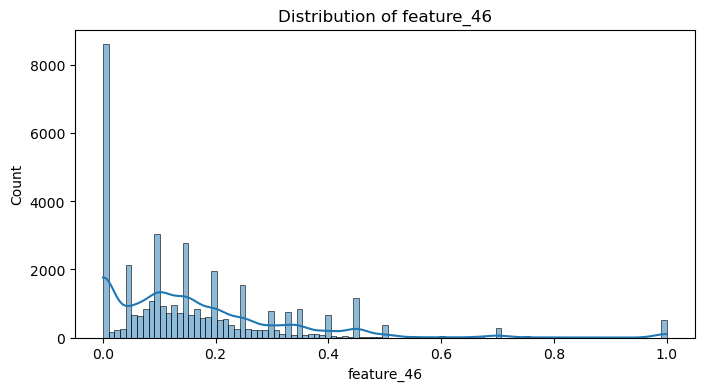

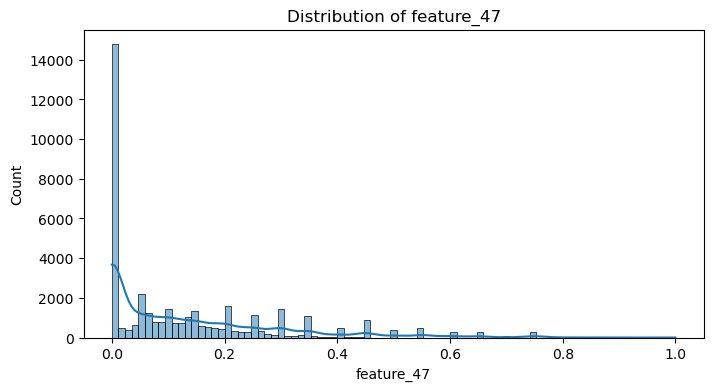

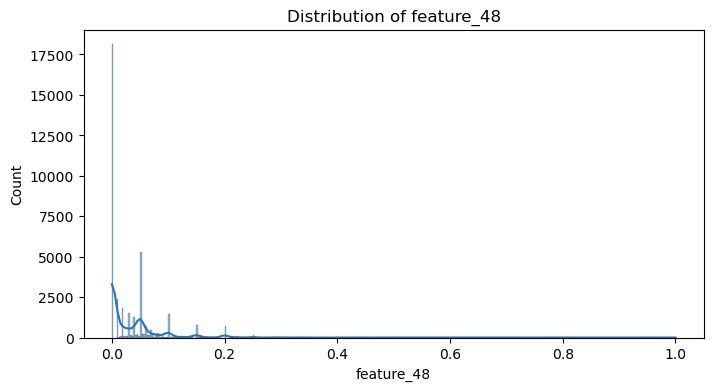

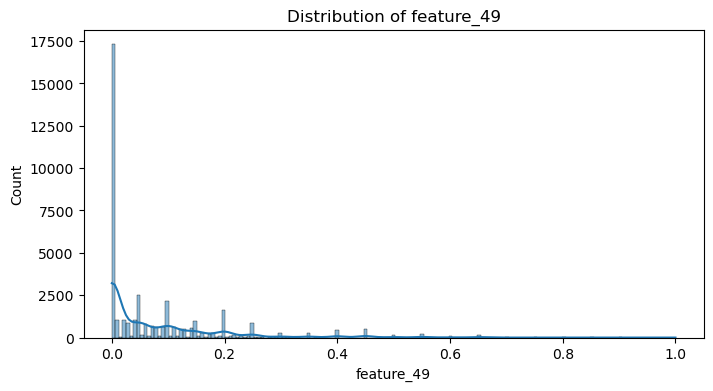

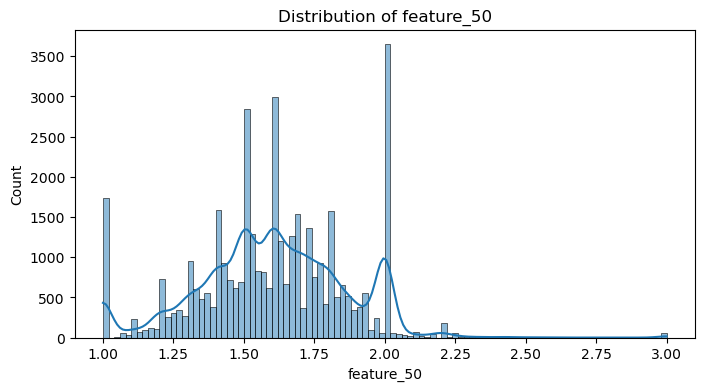

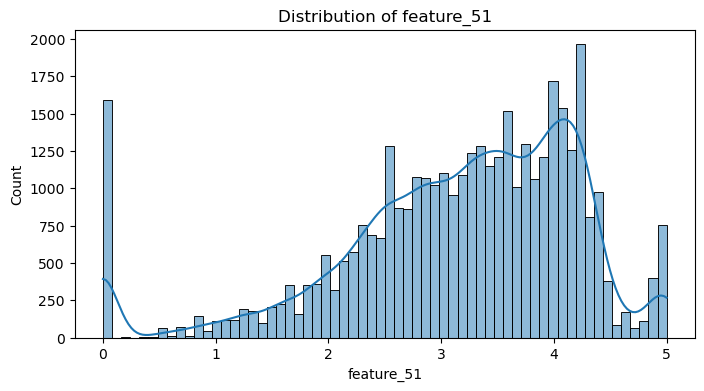

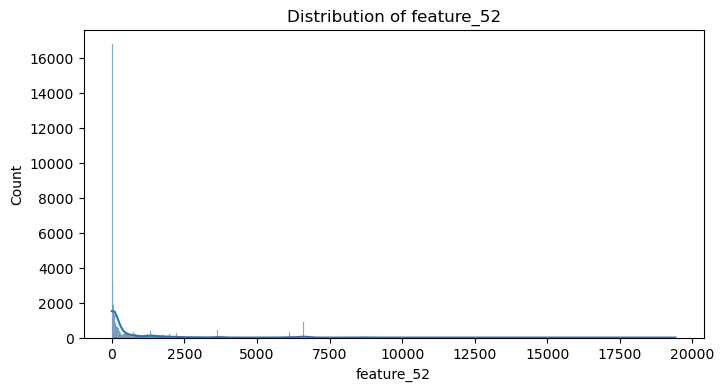

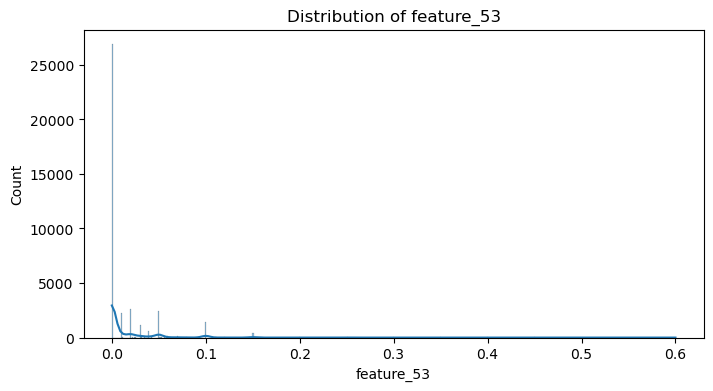

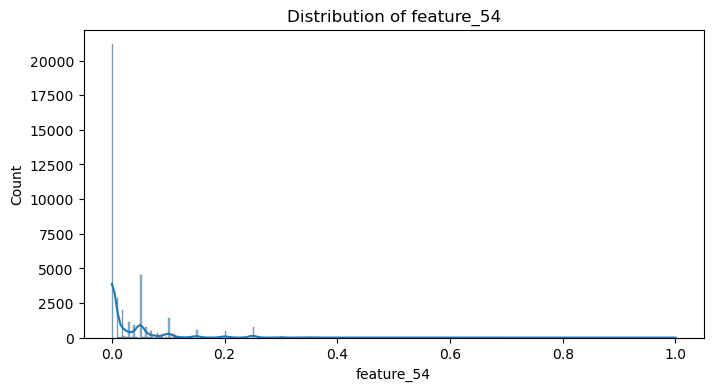

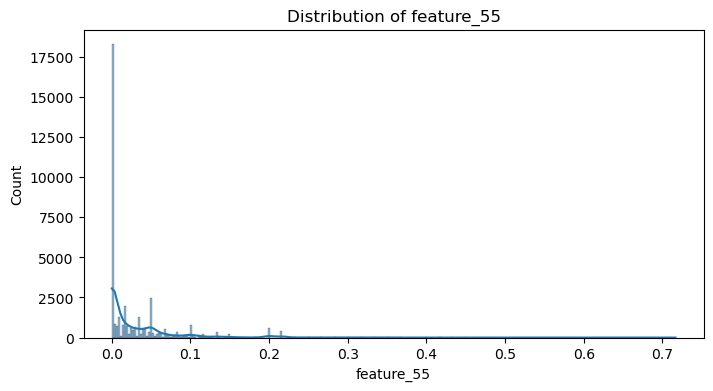

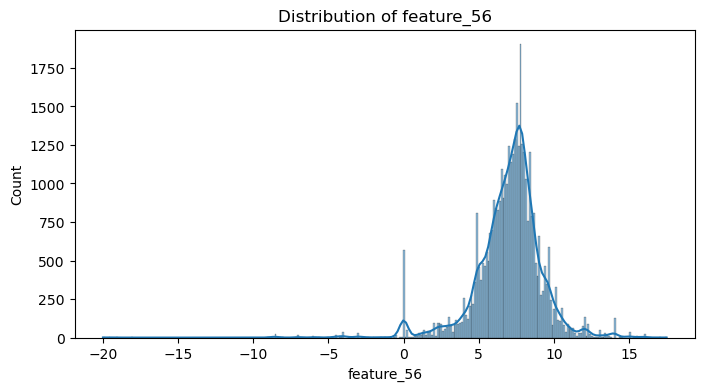

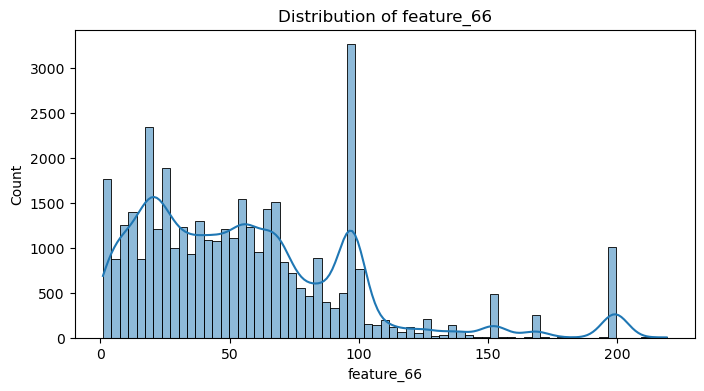

In [7]:
for col in ['feature_5', 'feature_6', 'feature_7', 'feature_10', 'feature_13',
       'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18',
       'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23',
       'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40',
       'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45',
       'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50',
       'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55',
       'feature_56', 'feature_66']:
    plt.figure(figsize=(8, 4))
    sns.histplot(Data_imputed_knn[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In the graphs we can see that the basic distribution for each column that used to have NaN values are the same.

### Save processed Data for model construction 

In [10]:
Save_path = os.path.join('..', 'data', 'processed', 'Data.pkl') 
os.makedirs(os.path.dirname(Save_path), exist_ok=True) 
Data.to_pickle(Save_path)

In [3]:
import pandas as pd
import os
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.utils import resample
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Configuración inicial
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Leer datos originales
Data = pd.read_csv('../Data/FPD.csv')

# Eliminar columnas constantes
constant_cols = [col for col in Data.columns if Data[col].nunique() == 1]
Data = Data.drop(columns=constant_cols)

# Separar ID si existe
Data_numeric = Data.drop(columns=['ID'], errors='ignore')

# Convertir booleanos a enteros
for col in Data_numeric.columns:
    if Data_numeric[col].dtype == 'bool':
        Data_numeric[col] = Data_numeric[col].astype(int)

# Función para guardar datos procesados
def save_processed_data(data, path_suffix):
    save_path = os.path.join('..', 'data', 'processed', f'Data_{path_suffix}.pkl')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    data.to_pickle(save_path)
    print(f"Datos guardados en: {save_path}")

# Versión base con KNNImputer (ya implementado)
knn_imputer = KNNImputer(n_neighbors=5)
Data_imputed_knn = pd.DataFrame(knn_imputer.fit_transform(Data_numeric), columns=Data_numeric.columns)
save_processed_data(Data_imputed_knn, 'knn_imputed')

# Versión con IterativeImputer
iterative_imputer = IterativeImputer(max_iter=10, random_state=42)
Data_imputed_iterative = pd.DataFrame(iterative_imputer.fit_transform(Data_numeric), columns=Data_numeric.columns)
save_processed_data(Data_imputed_iterative, 'iterative_imputed')

# Versión con tratamiento de outliers (Z-score)
z_scores = zscore(Data_numeric)
Data_no_outliers_z = Data_numeric[(z_scores < 3).all(axis=1)]
save_processed_data(Data_no_outliers_z, 'no_outliers_zscore')

# Versión con tratamiento de outliers (IQR)
Q1 = Data_numeric.quantile(0.25)
Q3 = Data_numeric.quantile(0.75)
IQR = Q3 - Q1
Data_no_outliers_iqr = Data_numeric[~((Data_numeric < (Q1 - 1.5 * IQR)) | (Data_numeric > (Q3 + 1.5 * IQR))).any(axis=1)]
save_processed_data(Data_no_outliers_iqr, 'no_outliers_iqr')

# Versión con PCA (reducción de dimensionalidad)
pca = PCA(n_components=0.95)  # Conserva el 95% de la varianza
Data_pca = pd.DataFrame(pca.fit_transform(Data_numeric))
save_processed_data(Data_pca, 'pca_reduced')

# Versión con selección de características (SelectKBest)
selector = SelectKBest(score_func=f_classif, k=50)  # Selecciona las 50 mejores características
Data_selected_features = pd.DataFrame(selector.fit_transform(Data_numeric, Data['target']))
save_processed_data(Data_selected_features, 'selected_features')

# Versión con escalamiento (StandardScaler)
scaler = StandardScaler()
Data_scaled_standard = pd.DataFrame(scaler.fit_transform(Data_numeric), columns=Data_numeric.columns)
save_processed_data(Data_scaled_standard, 'scaled_standard')

# Versión con escalamiento (MinMaxScaler)
minmax_scaler = MinMaxScaler()
Data_scaled_minmax = pd.DataFrame(minmax_scaler.fit_transform(Data_numeric), columns=Data_numeric.columns)
save_processed_data(Data_scaled_minmax, 'scaled_minmax')

# Versión con balanceo de clases (SMOTE)
X = Data_numeric.drop(columns=['target'])
y = Data_numeric['target']
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
Data_balanced_smote = pd.concat([X_resampled, y_resampled], axis=1)
save_processed_data(Data_balanced_smote, 'balanced_smote')

print("Procesamiento completado. Todas las versiones han sido guardadas.")

Datos guardados en: ..\data\processed\Data_knn_imputed.pkl


C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Datos guardados en: ..\data\processed\Data_iterative_imputed.pkl
Datos guardados en: ..\data\processed\Data_no_outliers_zscore.pkl
Datos guardados en: ..\data\processed\Data_no_outliers_iqr.pkl


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [5]:

# Configuración inicial
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Leer datos originales
Data = pd.read_csv('../Data/FPD.csv')

# Eliminar columnas constantes
constant_cols = [col for col in Data.columns if Data[col].nunique() == 1]
Data = Data.drop(columns=constant_cols)

# Separar ID si existe
Data_numeric = Data.drop(columns=['ID'], errors='ignore')

# Convertir booleanos a enteros
for col in Data_numeric.columns:
    if Data_numeric[col].dtype == 'bool':
        Data_numeric[col] = Data_numeric[col].astype(int)

# Función para guardar datos procesados
def save_processed_data(data, path_suffix):
    save_path = os.path.join('..', 'data', 'processed', f'Data_{path_suffix}.pkl')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    data.to_pickle(save_path)
    print(f"Datos guardados en: {save_path}")

# Versión base con KNNImputer (ya implementado)
knn_imputer = KNNImputer(n_neighbors=5)
Data_imputed_knn = pd.DataFrame(knn_imputer.fit_transform(Data_numeric), columns=Data_numeric.columns)
save_processed_data(Data_imputed_knn, 'knn_imputed')

# Versión con IterativeImputer
iterative_imputer = IterativeImputer(max_iter=10, random_state=42)
Data_imputed_iterative = pd.DataFrame(iterative_imputer.fit_transform(Data_numeric), columns=Data_numeric.columns)
save_processed_data(Data_imputed_iterative, 'iterative_imputed')

# Versión con tratamiento de outliers (Z-score)
z_scores = zscore(Data_numeric)
Data_no_outliers_z = Data_numeric[(z_scores < 3).all(axis=1)]
save_processed_data(Data_no_outliers_z, 'no_outliers_zscore')

# Versión con tratamiento de outliers (IQR)
Q1 = Data_numeric.quantile(0.25)
Q3 = Data_numeric.quantile(0.75)
IQR = Q3 - Q1
Data_no_outliers_iqr = Data_numeric[~((Data_numeric < (Q1 - 1.5 * IQR)) | (Data_numeric > (Q3 + 1.5 * IQR))).any(axis=1)]
save_processed_data(Data_no_outliers_iqr, 'no_outliers_iqr')

# Versión con PCA (reducción de dimensionalidad)
# Primero, asegúrate de que los datos estén imputados
Data_clean_for_pca = pd.DataFrame(knn_imputer.fit_transform(Data_numeric), columns=Data_numeric.columns)
scaler = StandardScaler()
Data_scaled_for_pca = scaler.fit_transform(Data_clean_for_pca)  # Escalar los datos antes de PCA
pca = PCA(n_components=0.95)  # Conserva el 95% de la varianza
Data_pca = pd.DataFrame(pca.fit_transform(Data_scaled_for_pca))
save_processed_data(Data_pca, 'pca_reduced')

# Versión con selección de características (SelectKBest)
selector = SelectKBest(score_func=f_classif, k=50)  # Selecciona las 50 mejores características
Data_selected_features = pd.DataFrame(selector.fit_transform(Data_numeric, Data['target']))
save_processed_data(Data_selected_features, 'selected_features')

# Versión con escalamiento (StandardScaler)
scaler = StandardScaler()
Data_scaled_standard = pd.DataFrame(scaler.fit_transform(Data_numeric), columns=Data_numeric.columns)
save_processed_data(Data_scaled_standard, 'scaled_standard')

# Versión con escalamiento (MinMaxScaler)
minmax_scaler = MinMaxScaler()
Data_scaled_minmax = pd.DataFrame(minmax_scaler.fit_transform(Data_numeric), columns=Data_numeric.columns)
save_processed_data(Data_scaled_minmax, 'scaled_minmax')

# Versión con balanceo de clases (SMOTE)
X = Data_numeric.drop(columns=['target'])
y = Data_numeric['target']
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
Data_balanced_smote = pd.concat([X_resampled, y_resampled], axis=1)
save_processed_data(Data_balanced_smote, 'balanced_smote')

print("Procesamiento completado. Todas las versiones han sido guardadas.")

Datos guardados en: ..\data\processed\Data_knn_imputed.pkl


C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Datos guardados en: ..\data\processed\Data_iterative_imputed.pkl
Datos guardados en: ..\data\processed\Data_no_outliers_zscore.pkl
Datos guardados en: ..\data\processed\Data_no_outliers_iqr.pkl
Datos guardados en: ..\data\processed\Data_pca_reduced.pkl


ValueError: Input X contains NaN.
SelectKBest does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [7]:
import pandas as pd
import os
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.stats import zscore
from imblearn.over_sampling import SMOTE

# Configuración inicial
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Leer datos originales
Data = pd.read_csv('../Data/FPD.csv')

# Eliminar columnas constantes
constant_cols = [col for col in Data.columns if Data[col].nunique() == 1]
Data = Data.drop(columns=constant_cols)

# Separar ID si existe
Data_numeric = Data.drop(columns=['ID'], errors='ignore')

# Convertir booleanos a enteros
for col in Data_numeric.columns:
    if Data_numeric[col].dtype == 'bool':
        Data_numeric[col] = Data_numeric[col].astype(int)

# Función para guardar datos procesados
def save_processed_data(data, path_suffix):
    save_path = os.path.join('..', 'data', 'processed', f'Data_{path_suffix}.pkl')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    data.to_pickle(save_path)
    print(f"Datos guardados en: {save_path}")

# Versión base con KNNImputer (ya implementado)
knn_imputer = KNNImputer(n_neighbors=5)
Data_imputed_knn = pd.DataFrame(knn_imputer.fit_transform(Data_numeric), columns=Data_numeric.columns)
save_processed_data(Data_imputed_knn, 'knn_imputed')

# Versión con tratamiento de outliers (Z-score)
z_scores = zscore(Data_imputed_knn)  # Usar datos ya imputados
Data_no_outliers_z = Data_imputed_knn[(z_scores < 3).all(axis=1)]
save_processed_data(Data_no_outliers_z, 'no_outliers_zscore')

# Versión con tratamiento de outliers (IQR)
Q1 = Data_imputed_knn.quantile(0.25)  # Usar datos ya imputados
Q3 = Data_imputed_knn.quantile(0.75)
IQR = Q3 - Q1
Data_no_outliers_iqr = Data_imputed_knn[~((Data_imputed_knn < (Q1 - 1.5 * IQR)) | (Data_imputed_knn > (Q3 + 1.5 * IQR))).any(axis=1)]
save_processed_data(Data_no_outliers_iqr, 'no_outliers_iqr')

# Versión con PCA (reducción de dimensionalidad)
scaler = StandardScaler()
Data_scaled_for_pca = scaler.fit_transform(Data_imputed_knn)  # Usar datos ya imputados
pca = PCA(n_components=0.95)  # Conserva el 95% de la varianza
Data_pca = pd.DataFrame(pca.fit_transform(Data_scaled_for_pca))
save_processed_data(Data_pca, 'pca_reduced')

# Versión con selección de características (SelectKBest)
selector = SelectKBest(score_func=f_classif, k=50)  # Selecciona las 50 mejores características
Data_selected_features = pd.DataFrame(selector.fit_transform(Data_imputed_knn, Data['target']))  # Usar datos ya imputados
save_processed_data(Data_selected_features, 'selected_features')

# Versión con escalamiento (StandardScaler)
scaler = StandardScaler()
Data_scaled_standard = pd.DataFrame(scaler.fit_transform(Data_imputed_knn), columns=Data_imputed_knn.columns)  # Usar datos ya imputados
save_processed_data(Data_scaled_standard, 'scaled_standard')

# Versión con escalamiento (MinMaxScaler)
minmax_scaler = MinMaxScaler()
Data_scaled_minmax = pd.DataFrame(minmax_scaler.fit_transform(Data_imputed_knn), columns=Data_imputed_knn.columns)  # Usar datos ya imputados
save_processed_data(Data_scaled_minmax, 'scaled_minmax')

# Versión con balanceo de clases (SMOTE)
X = Data_imputed_knn.drop(columns=['target'])  # Usar datos ya imputados
y = Data_imputed_knn['target']
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
Data_balanced_smote = pd.concat([X_resampled, y_resampled], axis=1)
save_processed_data(Data_balanced_smote, 'balanced_smote')

print("Procesamiento completado. Todas las versiones han sido guardadas.")

Datos guardados en: ..\data\processed\Data_knn_imputed.pkl
Datos guardados en: ..\data\processed\Data_no_outliers_zscore.pkl
Datos guardados en: ..\data\processed\Data_no_outliers_iqr.pkl
Datos guardados en: ..\data\processed\Data_pca_reduced.pkl
Datos guardados en: ..\data\processed\Data_selected_features.pkl


C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


Datos guardados en: ..\data\processed\Data_scaled_standard.pkl
Datos guardados en: ..\data\processed\Data_scaled_minmax.pkl


C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Datos guardados en: ..\data\processed\Data_balanced_smote.pkl
Procesamiento completado. Todas las versiones han sido guardadas.
